## Time Series Forecasting Fundamentals with TensorFlow

#### Let's predict the price of Bitcoin based on the historical price of Bitcoin.

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import datetime as dt
import os
import tensorflow as tf
warnings.filterwarnings("ignore")
print(tf.__version__)

2.18.0


## Get the data...

In [131]:
# !mkdir ~/.kaggle
# !cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download mczielinski/bitcoin-historical-data
!unzip bitcoin-historical-data

Dataset URL: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data
License(s): CC-BY-SA-4.0
... resuming from 117804632 bytes (0 bytes left) ...
416 - Requested range not satisfiable
Archive:  bitcoin-historical-data.zip
replace btcusd_1-min_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [132]:
df = pd.read_csv("/content/btcusd_1-min_data.csv")
df.head()

,Timestamp,Open,High,Low,Close,Volume,datetime
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:01:00+00:00
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:02:00+00:00
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:03:00+00:00
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:04:00+00:00
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:05:00+00:00


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6944800 entries, 0 to 6944799
Data columns (total 7 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
 6   datetime   object 
dtypes: float64(6), object(1)
memory usage: 370.9+ MB


In [134]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df['Date'] = pd.to_datetime(df['Timestamp'].dt.date)
df['Time'] = df['Timestamp'].dt.time
df.head()

,Timestamp,Open,High,Low,Close,Volume,datetime,Date,Time
0,2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:01:00+00:00,2012-01-01,10:01:00
1,2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:02:00+00:00,2012-01-01,10:02:00
2,2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:03:00+00:00,2012-01-01,10:03:00
3,2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:04:00+00:00,2012-01-01,10:04:00
4,2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:05:00+00:00,2012-01-01,10:05:00


In [135]:
df = df.drop(['Timestamp'], axis=1)
df.head()

,Open,High,Low,Close,Volume,datetime,Date,Time
0,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:01:00+00:00,2012-01-01,10:01:00
1,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:02:00+00:00,2012-01-01,10:02:00
2,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:03:00+00:00,2012-01-01,10:03:00
3,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:04:00+00:00,2012-01-01,10:04:00
4,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:05:00+00:00,2012-01-01,10:05:00


In [136]:
df = df.groupby('Date')['Close'].mean().reset_index()
df['Date'] = pd.to_datetime(df['Date'])
df.rename(columns={'Close':'Price'},inplace=True)
df.head()

,Date,Price
0,2012-01-01,4.645697
1,2012-01-02,4.975000
2,2012-01-03,5.085500
3,2012-01-04,5.170396
4,2012-01-05,5.954361


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4825 entries, 0 to 4824
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4825 non-null   datetime64[ns]
 1   Price   4825 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 75.5 KB


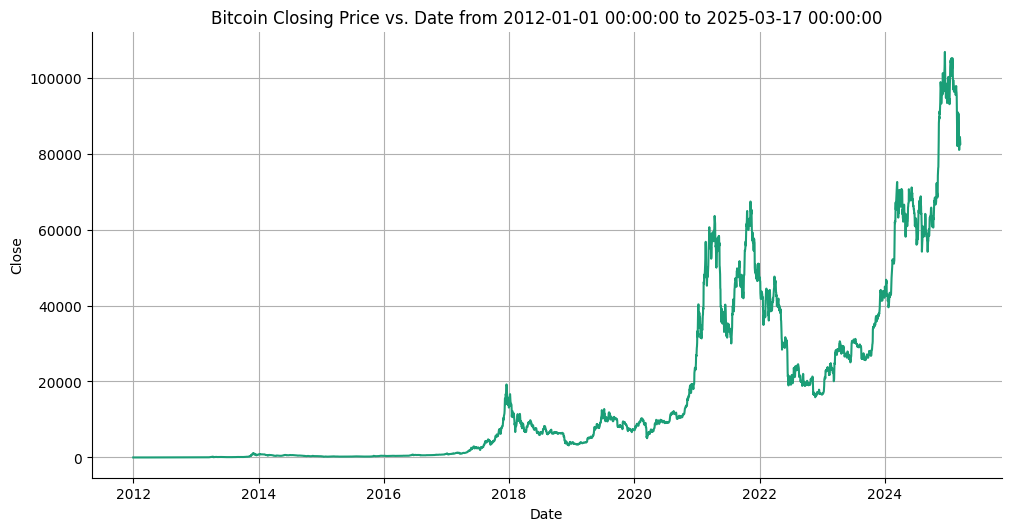

In [138]:
# @title Date vs Price

def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Price']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])
  plt.title(f"Bitcoin Closing Price vs. Date from {xs.min()} to {xs.max()}")
  plt.grid(True)
  return plt

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('Close')

#### Convert dataset columns to Numpy arrays.

In [139]:
timesteps = df['Date'].to_numpy()
prices = df['Price'].to_numpy()
timesteps,prices

(array(['2012-01-01T00:00:00.000000000', '2012-01-02T00:00:00.000000000',
        '2012-01-03T00:00:00.000000000', ...,
        '2025-03-15T00:00:00.000000000', '2025-03-16T00:00:00.000000000',
        '2025-03-17T00:00:00.000000000'], dtype='datetime64[ns]'),
 array([4.64569726e+00, 4.97500000e+00, 5.08550000e+00, ...,
        8.43606393e+04, 8.35781201e+04, 8.25660000e+04]))

#### Create train and test splits

In [140]:
split_size = int(np.size(timesteps) * 0.8)
X_train, X_test = timesteps[:split_size], timesteps[split_size:]
y_train, y_test = prices[:split_size], prices[split_size:]
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3860,), (965,), (3860,), (965,))

#### Plot train and test datasets.

In [141]:
# Create a function to plot time series data
def plot_time_series(timesteps, values, format='.', start=0, end=None, label=None):
  """
  Plots a timesteps (a series of points in time) against values (a series of values across timesteps).

  Parameters
  ---------
  timesteps : array of timesteps
  values : array of values across time
  format : style of plot, default "."
  start : where to start the plot (setting a value will index from start of timesteps & values)
  end : where to end the plot (setting a value will index from end of timesteps & values)
  label : label to show on plot of values
  """
  # Plot the series
  plt.plot(timesteps[start:end], values[start:end], format, label=label)
  plt.xlabel("Time")
  plt.ylabel("BTC Price")
  if label:
    plt.legend(fontsize=14) # make label bigger
  plt.grid(True)


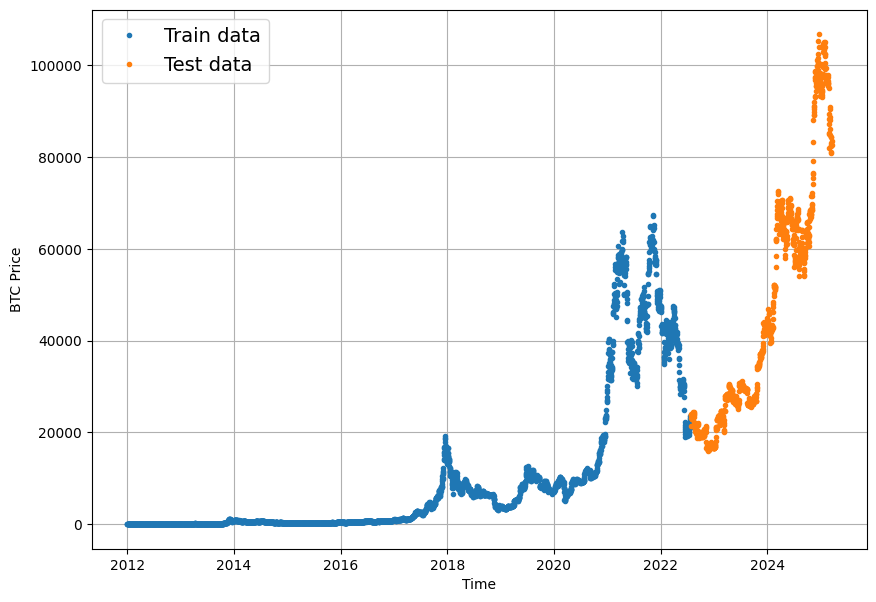

In [142]:
# Try out our plotting function
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_train, values=y_train, label="Train data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")

## Let's Build A Few Models.

Model Number | Model Type  | Horizon size | Window size | Extra data |
-------------|-------------|--------------|-------------|------------|
0 | Naive model (baseline) |    NA        |     NA      |  NA        |      
1 | Dense model            | 1 | 7 | NA |
2	|Same as 1	|1	|30	|NA|
3	|Same as 1|	7	|30	|NA|
4	|Conv1D	|1	|7	|NA|
5	|LSTM	|1	|7	|NA|
6	|Same as 1 (but with multivariate data)|	1|	7|	Block reward size
7	|N-BEATs Algorithm|	1	|7	|NA |
8	|Ensemble (multiple models optimized on different loss functions)|	1	|7	|NA
9	|Future prediction model (model to predict future values)|	1|	7	|NA|
10|	Same as 1 (but with turkey 🦃 data introduced)|	1	|7	|NA|


#### Model 0: Naive Forecast where   $\hat{y_t} = y_{t-1}$

In [143]:
# Create a naïve forecast
naive_forecast = y_test[:-1] # Naïve forecast equals every value excluding the last value
naive_forecast[:10], naive_forecast[-10:] # View first 10 and last 10

(array([21368.88505556, 23129.02411111, 23893.62595833, 24059.26191667,
        23771.4133125 , 23308.54152083, 22986.18859722, 23164.481     ,
        22953.27227778, 22983.18440972]),
 array([88039.46041667, 86183.99097222, 84344.68680556, 80953.91805556,
        81024.86736111, 82551.0625    , 82290.07986111, 83137.4375    ,
        84360.63928571, 83578.12013889]))

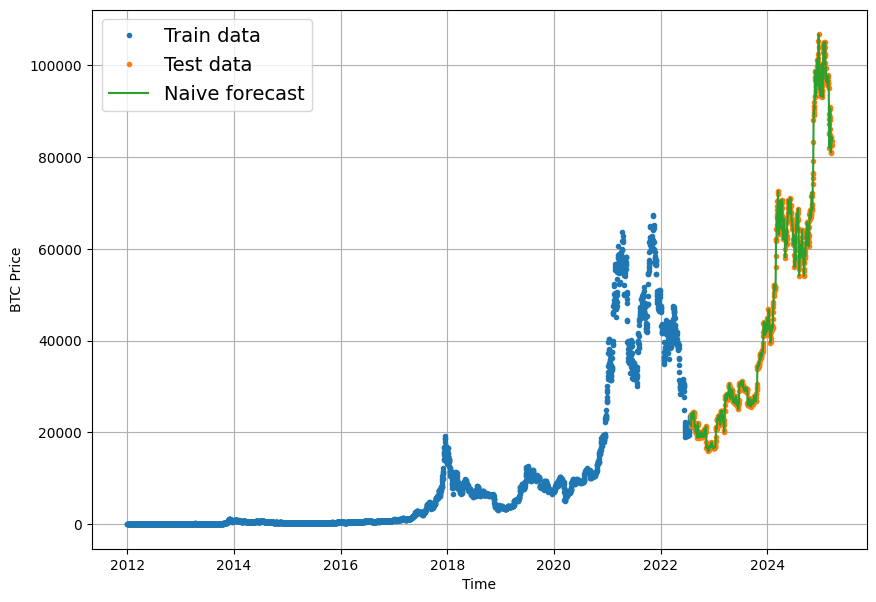

In [144]:
# Plot naive forecast
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_train, values=y_train, label="Train data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")
plot_time_series(timesteps=X_test[1:], values=naive_forecast, format="-", label="Naive forecast");

#### Let's zoom in on the above plot...

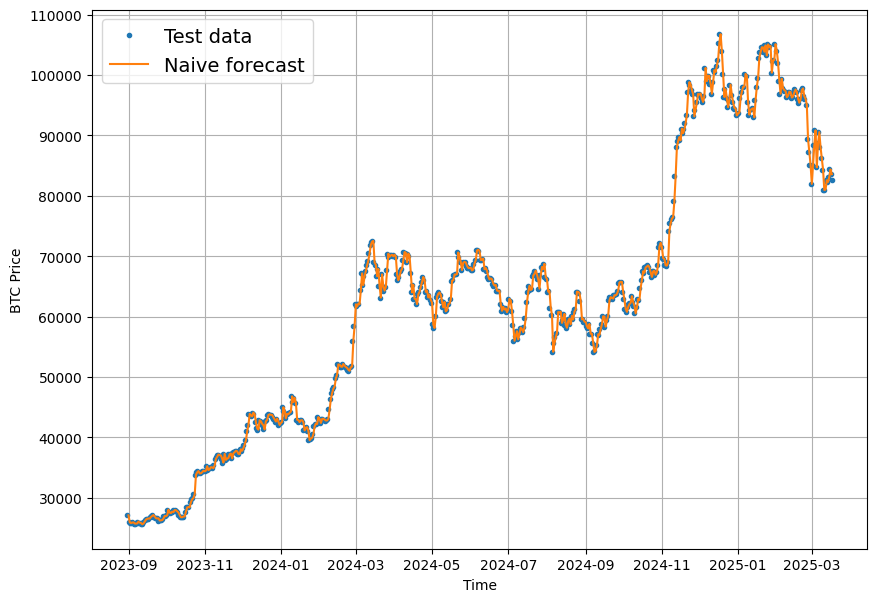

In [145]:
plt.figure(figsize=(10, 7))
offset = 400 # offset the values by 400 timesteps
plot_time_series(timesteps=X_test, values=y_test, start=offset, label="Test data")
plot_time_series(timesteps=X_test[1:], values=naive_forecast, format="-", start=offset, label="Naive forecast");


#### Scale-dependent errors

These are metrics which can be used to compare time series values and forecasts that are on the same scale.

For example, Bitcoin historical prices in USD versus Bitcoin forecast values in USD.

We can use

* `tf.keras.metrics.mean_absolute_error()`
* `tf.sqrt(tf.keras.metrics.mean_squared_error())`

In [146]:
# MASE implemented courtesy of sktime - https://github.com/alan-turing-institute/sktime/blob/ee7a06843a44f4aaec7582d847e36073a9ab0566/sktime/performance_metrics/forecasting/_functions.py#L16
def mean_absolute_scaled_error(y_true, y_pred):
  """
  Implement MASE (assuming no seasonality of data).
  """
  mae = tf.reduce_mean(tf.abs(y_true - y_pred))

  # Find MAE of naive forecast (no seasonality)
  mae_naive_no_season = tf.reduce_mean(tf.abs(y_true[1:] - y_true[:-1])) # our seasonality is 1 day (hence the shifting of 1 day)

  return mae / mae_naive_no_season

#### Set up instances of `mae`, `mse` and `mape`.

In [147]:
mae = tf.keras.losses.MeanAbsoluteError()
mse = tf.keras.losses.MeanSquaredError()
mape = tf.keras.losses.MeanAbsolutePercentageError()

In [148]:
def evaluate_preds(y_true, y_pred):
  # Make sure float32 (for metric calculations)
  y_true = tf.cast(y_true, dtype=tf.float32)
  y_pred = tf.cast(y_pred, dtype=tf.float32)

  # Calculate various metrics
  mae_result = mae(y_true, y_pred)
  mse_result = mse(y_true, y_pred) # puts and emphasis on outliers (all errors get squared)
  rmse = tf.sqrt(mse_result)
  mape_result = mape(y_true, y_pred)

  return {"mae": mae_result.numpy(),
          "mse": mse_result.numpy(),
          "rmse": rmse.numpy(),
          "mape": mape_result.numpy()}

In [149]:
naive_results = evaluate_preds(y_true=y_test[1:],
                               y_pred=naive_forecast)
naive_results

{'mae': np.float32(706.7882),
 'mse': np.float32(1278465.6),
 'rmse': np.float32(1130.6925),
 'mape': np.float32(1.4648389)}

In [ ]:
# Find average price of Bitcoin in test dataset
tf.reduce_mean(y_test).numpy()

np.float64(46549.19879264639)

Okay, looking at these two values is starting to give us an idea of how our model is performing:

The average price of Bitcoin in the test dataset is: $46,091 (note: average may not be the best measure here, since the highest price is over 3x this value and the lowest price is over 4x lower)

Each prediction in naive forecast is on average off by: $714.

Can we do better than this??

#### Windowing

Windowing is a method to turn a time series dataset into supervised learning problem.

In other words, we want to use windows of the past to predict the future.

For example for a univariate time series, windowing for one week (window=7) to predict the next single value (horizon=1) might look like:

```
Window for one week (univariate time series)

[0, 1, 2, 3, 4, 5, 6] -> [7]

[1, 2, 3, 4, 5, 6, 7] -> [8]

[2, 3, 4, 5, 6, 7, 8] -> [9]

```

In [ ]:
HORIZON = 1 # predict 1 step at a time
WINDOW_SIZE = 7 # use a week worth of timesteps to predict the horizon

In [ ]:
# Create function to label windowed data
def get_labeled_windows(x, horizon=1):
  """
  Creates labels for windowed dataset.

  E.g. if horizon=1 (default)
  Input: [1, 2, 3, 4, 5, 6] -> Output: ([1, 2, 3, 4, 5], [6])
  """
  return x[:, :-horizon], x[:, -horizon:]

In [ ]:
x = tf.expand_dims(np.array([1, 2, 3, 4, 5, 6]),axis=0)
x[:,:-1]

<tf.Tensor: shape=(1, 5), dtype=int64, numpy=array([[1, 2, 3, 4, 5]])>

In [ ]:
x[:,-1:]

<tf.Tensor: shape=(1, 1), dtype=int64, numpy=array([[6]])>

In [ ]:
get_labeled_windows(x, horizon=1)

(<tf.Tensor: shape=(1, 5), dtype=int64, numpy=array([[1, 2, 3, 4, 5]])>,
 <tf.Tensor: shape=(1, 1), dtype=int64, numpy=array([[6]])>)

In [ ]:
# Create function to view NumPy arrays as windows
def make_windows(x, window_size, horizon):
  """
  Turns a 1D array into a 2D array of sequential windows of window_size.
  """
  # 1. Create a window of specific window_size (add the horizon on the end for later labelling)
  window_step = np.expand_dims(np.arange(window_size+horizon), axis=0)
  # print(f"Window step:\n {window_step}")

  # 2. Create a 2D array of multiple window steps (minus 1 to account for 0 indexing)
  window_indexes = window_step + np.expand_dims(np.arange(len(x)-(window_size+horizon-1)), axis=0).T # create 2D array of windows of size window_size
  # print(f"Window indexes:\n {window_indexes[:3], window_indexes[-3:], window_indexes.shape}")

  # 3. Index on the target array (time series) with 2D array of multiple window steps
  windowed_array = x[window_indexes]

  # 4. Get the labelled windows
  windows, labels = get_labeled_windows(windowed_array, horizon=horizon)

  return windows, labels

#### The above function is broken out below for better understanding.

In [ ]:
# window_step = np.expand_dims(np.arange(WINDOW_SIZE+HORIZON), axis=0)
# window_step

In [ ]:
# window_indexes = window_step + np.expand_dims(np.arange(len(prices)-(WINDOW_SIZE+HORIZON-1)), axis=0).T
# window_indexes

In [ ]:
# windowed_array = prices[window_indexes]
# windowed_array

In [ ]:
# windows, labels = get_labelled_windows(windowed_array, horizon=HORIZON)
# windows, labels

#### Turning windowed data in train and test datasets...

In [ ]:
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
full_windows.shape, full_labels.shape

((4818, 7), (4818, 1))

In [ ]:
from posixpath import split
def make_train_test_splits(windows, labels, test_split=0.2):
  """
  Splits matching pairs of windows and labels into train and test splits.

  """
  split_size = int(len(windows) * (1-test_split))
  train_windows = windows[:split_size]
  test_windows = windows[split_size:]
  train_labels = labels[:split_size]
  test_labels = labels[split_size:]

  return train_windows, test_windows, train_labels, test_labels

In [ ]:
train_split = 0.8
split_size = int(len(full_windows) * train_split)
split_size

3854

In [ ]:
train_windows,test_windows,train_labels,test_labels = make_train_test_splits(full_windows, full_labels)
train_windows.shape, test_windows.shape, train_labels.shape, test_labels.shape

((3854, 7), (964, 7), (3854, 1), (964, 1))

Let's check to insure the train labels are the same before and after the window split.

In [ ]:
train_labels[:-HORIZON], train_labels[:-HORIZON].shape, y_train[WINDOW_SIZE:], y_train[WINDOW_SIZE:].shape

(array([[6.81944444e+00],
        [6.81645139e+00],
        [6.38572222e+00],
        ...,
        [2.25903409e+04],
        [2.20963947e+04],
        [2.11787013e+04]]),
 (3853, 1),
 array([6.81944444e+00, 6.81645139e+00, 6.38572222e+00, ...,
        2.25903409e+04, 2.20963947e+04, 2.11787013e+04]),
 (3853,))

Okay...looks good!

In [ ]:
np.array_equal(np.squeeze(train_labels[:-HORIZON]),y_train[WINDOW_SIZE:])

True

#### We need to make a modeling checkpoint to capture the best performance of each model at the epoch where the best performance is observed.

In [ ]:

import os

# Create a function to implement a ModelCheckpoint callback with a specific filename
def create_model_checkpoint(model_name, save_path="model_experiments"):
  return tf.keras.callbacks.ModelCheckpoint(filepath=os.path.join(save_path, model_name), # create filepath to save model
                                            verbose=0, # only output a limited amount of text
                                            save_best_only=True) # save only the best model to file

## `Model_1`:

* A single dense layer with 128 hidden units and ReLU (rectified linear unit) activation
* An output layer with linear activation (or no activation)
* Adam optimizer and MAE loss function
* Batch size of 128
* 100 epochs


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Set random seed for as reproducible results as possible
tf.random.set_seed(42)

# Construct model
model_1 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON, activation="linear") # linear activation is the same as having no activation
  ], name="model_1_dense.keras") # give the model a name so we can save it

# Compile model
model_1.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"]) # we don't necessarily need this when the loss function is already MAE

# Fit model
model_1.fit(x=train_windows, # train windows of 7 timesteps of Bitcoin prices
            y=train_labels, # horizon value of 1 (using the previous 7 timesteps to predict next day)
            epochs=100,
            verbose=0,
            batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_1.name)]) # create ModelCheckpoint callback to save best model



In [ ]:
# Evaluate model on test data
model_1.evaluate(test_windows, test_labels)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 471.4420 - mae: 471.4420


[752.7272338867188, 752.7272338867188]

In [ ]:
# Load in saved best performing model_1 and evaluate on test data
model_1 = tf.keras.models.load_model("model_experiments/model_1_dense.keras")
model_1.evaluate(test_windows, test_labels)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 446.9064 - mae: 446.9064


[713.0274658203125, 713.0274658203125]

## Making forecasts with a model (on the test dataset)

Since we're going to be running more modeling experiments, let's write a function which:

* Takes in a trained model (just like `model_1`)
* Takes in some input data (just like the data the model was trained on)
* Passes the input data to the model's `predict()` method
* Returns the predictions

In [123]:
def make_preds(model, input_data):
  """
  Uses model to make predictions on input_data.

  Parameters
  ----------
  model: trained model
  input_data: windowed input data (same kind of data model was trained on)

  Returns model predictions on input_data.
  """
  # forecast = model.predict(input_data)
  # return tf.squeeze(forecast) # return 1D array of predictions
  return model.predict(input_data)

In [ ]:
model_1_preds = make_preds(model_1, test_windows)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Compare `y_preds` to `test_labels`

In [ ]:
model_1_results = evaluate_preds(y_true=test_labels,
               y_pred=make_preds(model_1, test_windows))

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
model_1_results = evaluate_preds(y_true=test_labels,
               y_pred=make_preds(model_1, test_windows))
model_1_results

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


{'mae': np.float32(713.0274),
 'mse': np.float32(1284755.2),
 'rmse': np.float32(1133.4705),
 'mape': np.float32(1.4813151)}

How does this performance compare with the naive forecast?

In [ ]:
naive_results

{'mae': 725.0315, 'mse': 1546467.5, 'rmse': 1243.5704, 'mape': 1.4905553}

Okay, we see that `model_1` performs about as good as the naive model. We should be able to do better! 💪

Let's use the `plot_time_series()` function to plot `model_1_preds` against the test data.

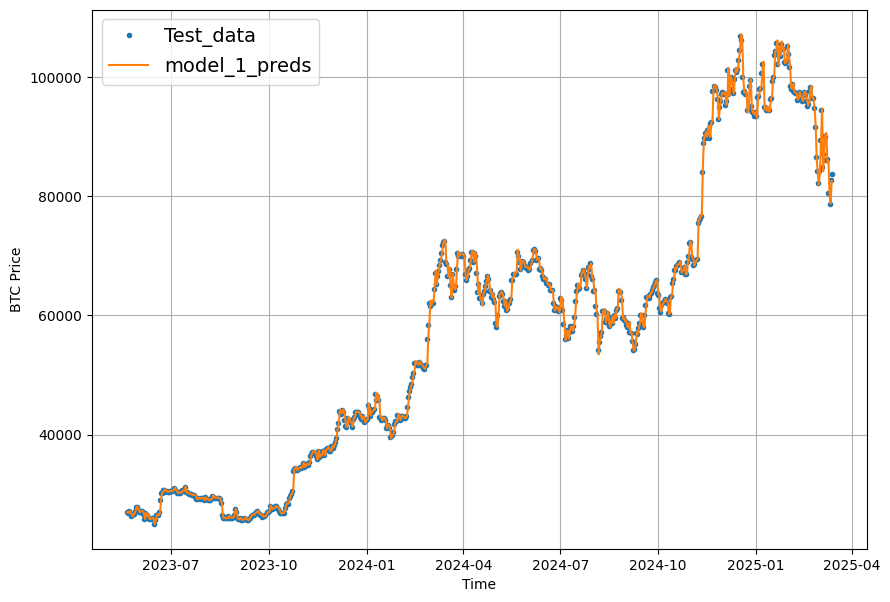

In [ ]:
offset = 300
plt.figure(figsize=(10, 7))
# Account for the test_window offset and index into test_labels to ensure correct plotting
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="Test_data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_1_preds, start=offset, format="-", label="model_1_preds")


## `Model_2`:

* Use `model_1` with a window_size = 30 and horizon = 1

In [ ]:
windows, labels = make_windows(prices, window_size=30, horizon=1)
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows, labels)
train_windows.shape, test_windows.shape, train_labels.shape, test_labels.shape

((3832, 30), (959, 30), (3832, 1), (959, 1))

In [ ]:
prices[:100], train_windows,train_labels

(array([4.64569726, 4.975     , 5.0855    , 5.17039583, 5.95436111,
        6.62033333, 6.04777778, 6.81944444, 6.81645139, 6.38572222,
        7.03033333, 6.97925   , 6.70711806, 6.49223611, 6.61107639,
        7.07152778, 7.00597222, 6.45834722, 6.53438889, 6.47508333,
        6.95      , 6.58236111, 6.60285417, 6.50035417, 6.59415278,
        6.27007639, 5.85440972, 5.27644444, 5.55984028, 5.45683333,
        5.66229167, 5.44102778, 6.03856944, 6.17535417, 6.30867361,
        5.92882639, 5.56186111, 5.66415278, 5.69008333, 5.78751389,
        5.88292361, 5.72289583, 5.53925   , 5.62697917, 5.31605556,
        4.88129861, 4.59868056, 4.68467361, 4.44534722, 4.31546528,
        4.46538194, 4.45179167, 4.50611806, 4.67306944, 5.10198611,
        5.00676389, 4.99197917, 4.99602778, 5.02986111, 4.96924306,
        5.011     , 4.83697222, 4.79349306, 4.68388194, 4.89986806,
        5.006875  , 5.01949306, 4.94740972, 5.01295139, 4.93270139,
        4.93958333, 4.98784722, 5.04125694, 5.34

In [ ]:
# Set random seed for as reproducible results as possible
tf.random.set_seed(42)

# Construct model
model_2 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON, activation="linear") # linear activation is the same as having no activation
  ], name="model_2_dense.keras") # give the model a name so we can save it

# Compile model
model_2.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"]) # we don't necessarily need this when the loss function is already MAE

# Fit model
model_2.fit(x=train_windows, # train windows of 7 timesteps of Bitcoin prices
            y=train_labels, # horizon value of 1 (using the previous 7 timesteps to predict next day)
            epochs=100,
            verbose=1,
            batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_2.name)]) # create ModelCheckpoint callback to save best model

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2059.6201 - mae: 2059.6201 - val_loss: 2020.1453 - val_mae: 2020.1453
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 626.3345 - mae: 626.3345 - val_loss: 1999.2379 - val_mae: 1999.2379
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 554.1208 - mae: 554.1208 - val_loss: 1700.6201 - val_mae: 1700.6201
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 507.4634 - mae: 507.4634 - val_loss: 1412.2118 - val_mae: 1412.2118
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 511.0413 - mae: 511.0413 - val_loss: 1483.9988 - val_mae: 1483.9988
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 456.3378 - mae: 456.3378 - val_loss: 2064.3774 - val_mae: 2064.3774
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 471.1810 - mae: 471.1810 - val_loss: 2057.8005 - val_mae: 2057.8005
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 447.6328 - mae: 447.6328 - val_loss: 1788.1628 - 

In [ ]:
# Evaluate model on test data
model_2.evaluate(test_windows, test_labels)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 875.0980 - mae: 875.0980 


[1377.3521728515625, 1377.3521728515625]

In [ ]:
# Load in saved best performing model_2 and evaluate on test data
model_2 = tf.keras.models.load_model("model_experiments/model_2_dense.keras")
model_2.evaluate(test_windows, test_labels)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 607.1326 - mae: 607.1326


[1000.6229858398438, 1000.6229858398438]

In [ ]:
model_2_preds = make_preds(model_2, test_windows)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
model_2_results = evaluate_preds(y_true=test_labels,
               y_pred=make_preds(model_2, test_windows))
model_2_results

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


{'mae': 1000.62305, 'mse': 2423043.8, 'rmse': 1556.6129, 'mape': 2.0867095}

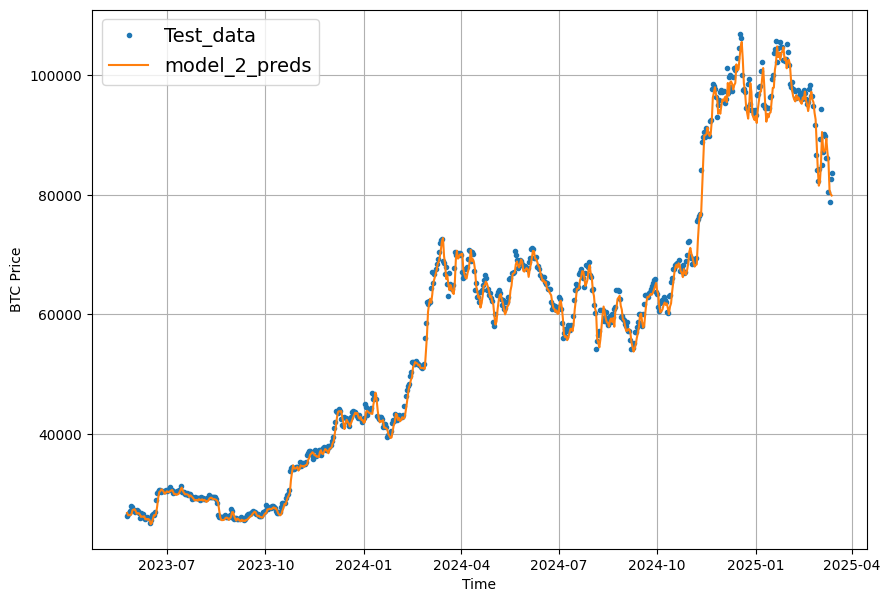

In [ ]:
offset = 300
plt.figure(figsize=(10, 7))
# Account for the test_window offset and index into test_labels to ensure correct plotting
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="Test_data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_2_preds, start=offset, format="-", label="model_2_preds")

## `Model_3`

* WINDOW_SIZE=30
* HORIZON=7

In [ ]:
HORIZON = 7
WINDOW_SIZE = 30

In [ ]:
def prepare_model_data(prices, window_size, horizon):

  # Prepare windows and labels and then split into train and test
  windows, labels = make_windows(prices, window_size=window_size, horizon=horizon)
  train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows, labels)
  return train_windows, test_windows, train_labels, test_labels

In [ ]:
def train_model(model_num, train_windows, test_windows, train_labels, test_labels, horizon):

  # Set random seed for as reproducible results as possible
  tf.random.set_seed(42)

  # Construct model
  model = tf.keras.Sequential([
      layers.Dense(128, activation="relu"),
      layers.Dense(horizon, activation="linear") # linear activation is the same as having no activation
      ], name=f"model_{model_num}_dense.keras") # give the model a name so we can save it

  # Compile model
  model.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"]) # we don't necessarily need this when the loss function is already MAE

  # Fit model
  model.fit(x=train_windows, # train_windows prices
            y=train_labels, # len(y) = horizon
            epochs=100,
            verbose=1,
            batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model.name)]) # create ModelCheckpoint callback to save best model

  model_evaluate = model.evaluate(test_windows, test_labels)

  # Load in saved best performing model_2 and evaluate on test data
  model = tf.keras.models.load_model(f"model_experiments/model_{model_num}_dense.keras")
  model.evaluate(test_windows, test_labels)
  model_preds = make_preds(model, test_windows)
  model_results = evaluate_preds(y_true=tf.squeeze(test_labels),
               y_pred=make_preds(model, test_windows))
  print(f"\nmodel_{model_num}_results: {model_results}")

  # Create plot of predictions

  print("\n\n")
  offset = 300
  plt.figure(figsize=(10, 7))
  # Account for the test_window offset and index into test_labels to ensure correct plotting
  plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="Test_data")
  plot_time_series(timesteps=X_test[-len(test_windows):], values=model_preds, start=offset, format="-", label=f"model_{model_num}_preds")

  return model_preds, model_results


Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 5047.2021 - mae: 5047.2021 - val_loss: 4880.1123 - val_mae: 4880.1123
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1235.6195 - mae: 1235.6195 - val_loss: 3165.3496 - val_mae: 3165.3496
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 952.5096 - mae: 952.5096 - val_loss: 2596.1765 - val_mae: 2596.1765
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 826.4830 - mae: 826.4830 - val_loss: 2353.1035 - val_mae: 2353.1035
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 773.2635 - mae: 773.2635 - val_loss: 2311.2754 - val_mae: 2311.2754
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 732.9530 - mae: 732.9530 - val_loss: 2271.3953 - val_mae: 2271.3953
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 716.8967 - mae: 716.8967 - val_loss: 2248.2256 - val_mae: 2248.2256
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 706.5149 - mae: 706.5149 - val_loss: 2150.5696 

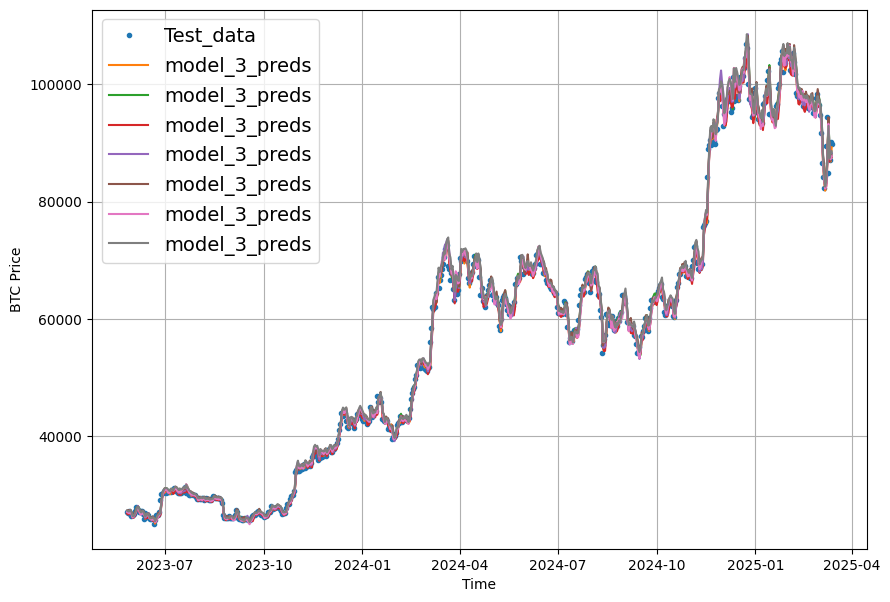

In [ ]:
train_windows, test_windows, train_labels, test_labels = prepare_model_data(prices, window_size=30, horizon=HORIZON)
model_preds, model_results = train_model(model_num=3, train_windows=train_windows, test_windows=test_windows, train_labels=train_labels, test_labels=test_labels, horizon=HORIZON)


## `Model_4: Conv1D`

`Conv1D` models can be used for `seq2seq` (sequence to sequence) problems.

In this case, the input sequence is the previous 7 days of Bitcoin price data and the output is the next day (in `seq2seq` terms this is called a many to one problem).

In [ ]:
HORIZON=1
WINDOW_SIZE=7

# Create windowed dataset
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
full_windows.shape, full_labels.shape


((4814, 7), (4814, 1))

In [ ]:
# Create train/test splits
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels)
train_windows.shape, test_windows.shape, train_labels.shape, test_labels.shape
#

((3851, 7), (963, 7), (3851, 1), (963, 1))

The Conv1D layer in TensorFlow takes an input of: (`batch_size`, `timesteps`, `input_dim`).

In our case, the `batch_size` (by default this is 32 but we can change it) is handled for us but the other values will be:

* `timesteps = WINDOW_SIZE`  - the `timesteps` is also often referred to as features, our features are the previous `WINDOW_SIZE` values of Bitcoin
* `input_dim = HORIZON` - our model views `WINDOW_SIZE` (one week) worth of data at a time to predict `HORIZON` (one day)

Right now, our data has the `timesteps` dimension ready but we'll have to adjust it to have the `input_dim` dimension.

In [ ]:
# Check data sample shapes
train_windows[0].shape # returns (WINDOW_SIZE, )

(7,)

To fix this, we could adjust the shape of all of our `train_windows` or we could use a `tf.keras.layers.Lamdba` (called a Lambda layer) to do this for us in our model.

The Lambda layer wraps a function into a layer which can be used with a model.

In [ ]:
# Before we pass the data to the Conv1D layer, we have to reshape it in order to make sure it works
x = tf.constant(train_windows[0])
expand_dims_layer = layers.Lambda(lambda x: tf.expand_dims(x, axis=1)) # add an extra dimension for timesteps
print(f"Original shape: {x.shape}") # (WINDOW_SIZE)
print(f"Expanded shape: {expand_dims_layer(x).shape}") # (WINDOW_SIZE, input_dim)
print(f"Original values with expanded shape:\n {expand_dims_layer(x)}")


Original shape: (7,)
Expanded shape: (7, 1)
Original values with expanded shape:
 [[4.645697 ]
 [4.975    ]
 [5.0855   ]
 [5.170396 ]
 [5.954361 ]
 [6.620333 ]
 [6.0477777]]


In [ ]:
tf.random.set_seed(42)

def expd_dim(x):
  return tf.expand_dims(x,axis=1)

# Create model
model_4 = tf.keras.Sequential([
  # Create Lambda layer to reshape inputs, without this layer, the model will error
  layers.Lambda(expd_dim), # resize the inputs to adjust for window size / Conv1D 3D input requirements
  layers.Conv1D(filters=128, kernel_size=5, padding="causal", activation="relu"),
  layers.Dense(HORIZON)
], name="model_4_conv1D.keras")

# Compile model
model_4.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

# Fit model
model_4.fit(train_windows,
            train_labels,
            batch_size=128,
            epochs=100,
            verbose=0,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_4.name)])

In [ ]:
model_4.summary()

Model: "model_4_conv1D.keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)                    │ (None, 1, 7)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 1, 128)              │           4,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1, 1)                │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,213 (55.52 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,476 (37.02 KB)

In [ ]:
# Load in best performing Conv1D model and evaluate it on the test data
model_4 = tf.keras.models.load_model("model_experiments/model_4_conv1D.keras",
                                   custom_objects={"expd_dim": expd_dim})
model_4.evaluate(test_windows, test_labels)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 456.3993  


740.7418212890625

In [ ]:
# Make predictions
model_4_preds = make_preds(model_4, test_windows)
model_4_preds = np.squeeze(model_4_preds)
model_4_preds.shape

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


(963,)

In [ ]:
# Evaluate predictions
model_4_results = evaluate_preds(y_true=tf.squeeze(test_labels),
                                 y_pred=model_4_preds)
model_4_results

{'mae': 740.7419, 'mse': 1594080.0, 'rmse': 1262.5688, 'mape': 1.5267885}

## `Model_5: RNN (LSTM)`

Once again, one of the most important steps for the LSTM model will be getting the data into the right shape.

The `tf.keras.layers.LSTM()` layer takes a tensor with `[batch, timesteps, feature]` dimensions.

As mentioned earlier, the batch dimension gets taken care of for us but our data is currently only has the feature dimension (`WINDOW_SIZE`).

To fix this, just like we did with the `Conv1D` model, we can use a `tf.keras.layers.Lambda()` layer to adjust the shape of our input tensors to the LSTM layer.

In [ ]:
tf.random.set_seed(42)

# Let's build an LSTM model with the Functional API
inputs = layers.Input(shape=(WINDOW_SIZE,))
x = layers.Lambda(expd_dim)(inputs) # expand input dimension to be compatible with LSTM
# print(x.shape)
# x = layers.LSTM(128, activation="relu", return_sequences=True)(x) # this layer will error if the inputs are not the right shape
x = layers.LSTM(128, activation="relu")(x) # using the tanh loss function results in a massive error
# print(x.shape)
# Add another optional dense layer (you could add more of these to see if they improve model performance)
# x = layers.Dense(32, activation="relu")(x)
output = layers.Dense(HORIZON)(x)
model_5 = tf.keras.Model(inputs=inputs, outputs=output, name="model_5_lstm.keras")

# Compile model
model_5.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

# Seems when saving the model several warnings are appearing: https://github.com/tensorflow/tensorflow/issues/47554
model_5.fit(train_windows,
            train_labels,
            epochs=100,
            verbose=0,
            batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_5.name)])

In [ ]:
# Load in best version of model 5 and evaluate on the test data
model_5 = tf.keras.models.load_model("model_experiments/model_5_lstm.keras",
                        custom_objects={"expd_dim": expd_dim})
model_5.evaluate(test_windows, test_labels)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 592.0861


959.697021484375

In [ ]:
# Make predictions with our LSTM model
model_5_preds = make_preds(model_5, test_windows)
model_5_preds[:10]

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


array([[22329.365],
       [22014.281],
       [21053.137],
       [20928.77 ],
       [22270.84 ],
       [23507.633],
       [23896.406],
       [23808.633],
       [23355.113],
       [22915.992]], dtype=float32)

In [ ]:
model_5_results = evaluate_preds(y_true=tf.squeeze(test_labels),
                                 y_pred=model_5_preds)
model_5_results

{'mae': 959.697, 'mse': 2201341.5, 'rmse': 1483.6919, 'mape': 1.995773}

In [ ]:
naive_results

{'mae': 725.0315, 'mse': 1546467.5, 'rmse': 1243.5704, 'mape': 1.4905553}

## `Model_6`: `Model_1` Using Multivariate Time Series

#### Bitcoin Halving Dates

|Date| Halving Event|
|----------|-----------------|
|11/28/2012| 50 BTC -> 25 BTC|
|7/9/2016| 25 BTC -> 12.5 BTC|
|5/11/2020| 12.5 BTC -> 6.25 BTC|
|4/19/2024| 6.25 BTC -> 3.125 BTC|

In [ ]:
halving_date_1 = np.datetime64("2012-11-28")
halving_date_2 = np.datetime64("2016-07-09")
halving_date_3 = np.datetime64("2020-05-11")
halving_date_4 = np.datetime64("2024-04-19")

In [ ]:
block_reward_1_days = (halving_date_1-df['Date'][0]).days
block_reward_2_days = (halving_date_2-df['Date'][0]).days
block_reward_3_days = (halving_date_3-df['Date'][0]).days
block_reward_4_days = (halving_date_4-df['Date'][0]).days
block_reward_1_days, block_reward_2_days, block_reward_3_days, block_reward_4_days

(332, 1651, 3053, 4492)

In [ ]:
df['Block_Reward'] = None

In [ ]:
df.head()

,Date,Price,Block_Reward
0,2012-01-01,4.645697,None
1,2012-01-02,4.975000,None
2,2012-01-03,5.085500,None
3,2012-01-04,5.170396,None
4,2012-01-05,5.954361,None


In [ ]:
df['Block_Reward'][:block_reward_1_days] = 50
df['Block_Reward'][block_reward_1_days:block_reward_2_days] = 25
df['Block_Reward'][block_reward_2_days:block_reward_3_days] = 12.5
df['Block_Reward'][block_reward_3_days:block_reward_4_days] = 6.25

In [ ]:
df.head()

,Date,Price,Block_Reward
0,2012-01-01,4.645697,50
1,2012-01-02,4.975000,50
2,2012-01-03,5.085500,50
3,2012-01-04,5.170396,50
4,2012-01-05,5.954361,50


#### Let's generate a plot to ensure we've done things correctly...

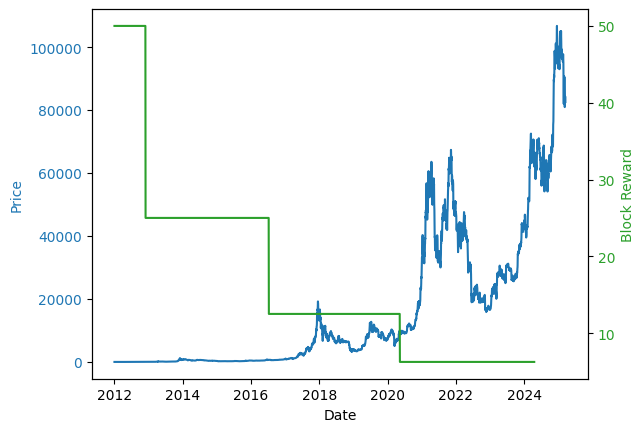

<Figure size 1000x700 with 0 Axes>

<Figure size 1000x700 with 0 Axes>

<Figure size 1000x700 with 0 Axes>

In [ ]:
fig, ax1 = plt.subplots()
plt.figure(figsize=(10, 7))
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Price', color=color)
ax1.plot(df['Date'], df['Price'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:green'
ax2.set_ylabel('Block Reward', color=color,rotation=90)  # we already handled the x-label with ax1
ax2.plot(df['Date'], df['Block_Reward'], color=color)
ax2.tick_params(axis='y', labelcolor=color)
plt.figure(figsize=(10, 7))
# fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.figure(figsize=(10, 7))
plt.show()

#### Now, we need to make a windowed dataset with pandas.   Since the data is in a pandas DataFrame, we can leverage the `pandas.DataFrame.shift(`) method to create a windowed multivariate time series.

In [ ]:
WINDOW_SIZE = 7
HORIZON = 1

In [ ]:
# Make a copy of the Bitcoin historical data with block reward feature
df_windowed = df.copy()

# Add windowed columns
for i in range(WINDOW_SIZE): # Shift values for each step in WINDOW_SIZE
  df_windowed[f"Price+{i+1}"] = df_windowed["Price"].shift(periods=i+1)
df_windowed.head(10)

,Date,Price,Block_Reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
0,2012-01-01,4.645697,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-02,4.975000,50,4.645697,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-01-03,5.085500,50,4.975000,4.645697,NaN,NaN,NaN,NaN,NaN
3,2012-01-04,5.170396,50,5.085500,4.975000,4.645697,NaN,NaN,NaN,NaN
4,2012-01-05,5.954361,50,5.170396,5.085500,4.975000,4.645697,NaN,NaN,NaN
5,2012-01-06,6.620333,50,5.954361,5.170396,5.085500,4.975000,4.645697,NaN,NaN
6,2012-01-07,6.047778,50,6.620333,5.954361,5.170396,5.085500,4.975000,4.645697,NaN
7,2012-01-08,6.819444,50,6.047778,6.620333,5.954361,5.170396,5.085500,4.975000,4.645697
8,2012-01-09,6.816451,50,6.819444,6.047778,6.620333,5.954361,5.170396,5.085500,4.975000
9,2012-01-10,6.385722,50,6.816451,6.819444,6.047778,6.620333,5.954361,5.170396,5.085500


Now that we've got a windowed dataset, let's separate features ($X$) from labels ($y$).

Remember in our windowed dataset, we're trying to use the previous `WINDOW_SIZE` steps to predict `HORIZON` steps.

Window for a week (7) to predict a horizon of 1 (multivariate time series)
WINDOW_SIZE & block_reward -> HORIZON

[0, 1, 2, 3, 4, 5, 6, block_reward] -> [7]

[1, 2, 3, 4, 5, 6, 7, block_reward] -> [8]

[2, 3, 4, 5, 6, 7, 8, block_reward] -> [9]

We'll also remove the `NaN` values using pandas `dropna()` method, this is equivalent to starting our windowing function at sample 0 (the first sample) + `WINDOW_SIZE`.

In [ ]:
df_windowed = df_windowed.dropna()
df_windowed = df_windowed.set_index('Date')
df_windowed.head()

,Price,Block_Reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,,
2012-01-08,6.819444,50,6.047778,6.620333,5.954361,5.170396,5.085500,4.975000,4.645697
2012-01-09,6.816451,50,6.819444,6.047778,6.620333,5.954361,5.170396,5.085500,4.975000
2012-01-10,6.385722,50,6.816451,6.819444,6.047778,6.620333,5.954361,5.170396,5.085500
2012-01-11,7.030333,50,6.385722,6.816451,6.819444,6.047778,6.620333,5.954361,5.170396
2012-01-12,6.979250,50,7.030333,6.385722,6.816451,6.819444,6.047778,6.620333,5.954361


In [ ]:
# Let's create X & y, remove the NaN's and convert to float32 to prevent TensorFlow errors
X = df_windowed.drop("Price", axis=1).astype(np.float32)
y = df_windowed["Price"].astype(np.float32)
X.head()

,Block_Reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,
2012-01-08,50.0,6.047778,6.620333,5.954361,5.170396,5.085500,4.975000,4.645697
2012-01-09,50.0,6.819445,6.047778,6.620333,5.954361,5.170396,5.085500,4.975000
2012-01-10,50.0,6.816452,6.819445,6.047778,6.620333,5.954361,5.170396,5.085500
2012-01-11,50.0,6.385722,6.816452,6.819445,6.047778,6.620333,5.954361,5.170396
2012-01-12,50.0,7.030334,6.385722,6.816452,6.819445,6.047778,6.620333,5.954361


In [ ]:
y.head()

,Price
Date,
2012-01-08,6.819445
2012-01-09,6.816452
2012-01-10,6.385722
2012-01-11,7.030334
2012-01-12,6.979250


In [ ]:
# Make train and test sets
split_size = int(len(X) * 0.8)
X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]
len(X_train), len(y_train), len(X_test), len(y_test)

(3588, 3588, 897, 897)

#### `Model_6:` Similar to `Model_1` with `block_reward` feature added

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

tf.random.set_seed(42)

# Make multivariate time series model
model_6 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(128, activation="relu"), # adding an extra layer here should lead to beating the naive model
  layers.Dense(HORIZON)
], name="model_6_dense_multivariate.keras")

# Compile
model_6.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

# Fit
model_6.fit(X_train, y_train,
            epochs=100,
            batch_size=128,
            verbose=0, # only print 1 line per epoch
            validation_data=(X_test, y_test),
            callbacks=[create_model_checkpoint(model_name=model_6.name)])

In [ ]:
# Make sure best model is loaded and evaluate
model_6 = tf.keras.models.load_model("model_experiments/model_6_dense_multivariate.keras")
model_6.evaluate(X_test, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 709.8124   


573.6741333007812

In [ ]:
# Make predictions on multivariate data
model_6_preds = tf.squeeze(model_6.predict(X_test))
model_6_preds[:10]

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([63053.77 , 62152.707, 61489.31 , 60830.348, 61884.047, 65393.25 ,
       67694.414, 67465.24 , 65020.41 , 64272.004], dtype=float32)>

In [ ]:
# Evaluate preds
model_6_results = evaluate_preds(y_true=y_test,
                                 y_pred=model_6_preds)
model_6_results

{'mae': np.float32(573.67413),
 'mse': np.float32(817150.44),
 'rmse': np.float32(903.96375),
 'mape': np.float32(1.6611519)}

In [ ]:
model_1_results

{'mae': np.float32(713.0274),
 'mse': np.float32(1284755.2),
 'rmse': np.float32(1133.4705),
 'mape': np.float32(1.4813151)}

In [ ]:
naive_results

{'mae': np.float32(706.7882),
 'mse': np.float32(1278465.6),
 'rmse': np.float32(1130.6925),
 'mape': np.float32(1.4648389)}

#### It looks like adding the `block_reward` feature does improve the model performance!

## `Model_7: N-BEATS` - Neural Basis Expansion Analysis For Interpretable Time Series Forecasting

So, why N-BEATS?

* Allows for practice replicating a paper with Tensorflow code.
* We will see how to use TensorFlow subclassing to make customer layers.
* Get experience using the Functional API to create a custom architecture.


![figure 1 from N-BBEATS paper, the algorithm we're going to build](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-figure-1-nbeats-paper-annotated.png)
**N-BEATS algorithm to be replicated with TensorFlow with window (input) and horizon (output) annotations.**

Setting up the `NBeatsBlock` custom layer we see:

* The class inherits from `tf.keras.layers.Layer` (this gives it all of the methods associated with `tf.keras.layers.Layer`).
* The constructor (`def __init__(...)`) takes all of the layer hyperparameters as well as the `**kwargs` argument.
* The `**kwargs` argument takes care of all of the hyperparameters which aren't mentioned in the constructor such as `input_shape`, `trainable` and `name`.
In the constructor, the block architecture layers are created:
* The hidden layers are created as a stack of fully connected `n_nuerons` hidden unit layers with `ReLU` activation.
* The theta layer uses `theta_size` hidden units as well as `linear` activation.
* The `call()` method is run when the layer is called:
  - It first passes the inputs (the historical Bitcoin data) through each of the hidden layers (a stack of fully connected layers with `ReLU` activation)
  - After the inputs have been through each of the fully connected layers, they get passed through the theta layer where the backcast (backwards predictions, shape: `input_size`) and forecast (forward predictions, shape: `horizon`) are returned.

In [14]:
# Create NBeatsBlock custom layer
class NBeatsBlock(tf.keras.layers.Layer):
  def __init__(self, # the constructor takes all the hyperparameters for the layer
               input_size: int,
               theta_size: int,
               horizon: int,
               n_neurons: int,
               n_layers: int,
               **kwargs): # the **kwargs argument takes care of all of the arguments for the parent class (input_shape, trainable, name)
    super().__init__(**kwargs)
    self.input_size = input_size
    self.theta_size = theta_size
    self.horizon = horizon
    self.n_neurons = n_neurons
    self.n_layers = n_layers

    # Block contains stack of 4 fully connected layers each has ReLU activation
    self.hidden = [tf.keras.layers.Dense(n_neurons, activation="relu") for _ in range(n_layers)]
    # Output of block is a theta layer with linear activation
    self.theta_layer = tf.keras.layers.Dense(theta_size, activation="linear", name="theta")

  def call(self, inputs): # the call method is what runs when the layer is called
    x = inputs
    for layer in self.hidden: # pass inputs through each hidden layer
      x = layer(x)
    theta = self.theta_layer(x)
    # Output the backcast and forecast from theta
    backcast, forecast = theta[:, :self.input_size], theta[:, -self.horizon:]
    return backcast, forecast

Let's test the Class using some dummy inputs and outputs.

In [15]:
WINDOW_SIZE=7
HORIZON=1

In [16]:
# Set up dummy NBeatsBlock layer to represent inputs and outputs
dummy_nbeats_block_layer = NBeatsBlock(input_size=WINDOW_SIZE,
                                       theta_size=WINDOW_SIZE+HORIZON, # backcast + forecast
                                       horizon=HORIZON,
                                       n_neurons=128,
                                       n_layers=4)

In [17]:
# Create dummy inputs (have to be same size as input_size)
dummy_inputs = tf.expand_dims(tf.range(WINDOW_SIZE) + 1, axis=0) # input shape to the model has to reflect Dense layer input requirements (ndim=2)
dummy_inputs

<tf.Tensor: shape=(1, 7), dtype=int32, numpy=array([[1, 2, 3, 4, 5, 6, 7]], dtype=int32)>

In [18]:
# Pass dummy inputs to dummy NBeatsBlock layer
backcast, forecast = dummy_nbeats_block_layer(dummy_inputs)
# These are the activation outputs of the theta layer (they'll be random due to no training of the model)
print(f"Backcast: {tf.squeeze(backcast.numpy())}")
print(f"Forecast: {tf.squeeze(forecast.numpy())}")

Backcast: [-0.0275275  -0.14690354  0.5985106   0.6577872   0.40535095  0.7673698
  0.22600581]
Forecast: 1.0738716125488281


#### Preparing data for the N-BEATS algorithm using `tf.data`

Because we're using a larger model architecture, we'll setup the datasets using the `tf.data` API to ensure the model training runs as fast as possible. Recalling the original Bitcoin price dataset:

In [29]:
df.head()

,Date,Price
0,2012-01-01,4.645697
1,2012-01-02,4.975000
2,2012-01-03,5.085500
3,2012-01-04,5.170396
4,2012-01-05,5.954361


Move `Date` column to be the dataframe index and add windowed columns and drop rows where there are subsequent `NULL`s....

In [101]:
bitcoin_prices_nbeats = df.copy()
bitcoin_prices_nbeats.set_index("Date", inplace=True)
bitcoin_prices_nbeats.head()


,Price
Date,
2012-01-01,4.645697
2012-01-02,4.975000
2012-01-03,5.085500
2012-01-04,5.170396
2012-01-05,5.954361


In [102]:
for i in range(WINDOW_SIZE):
  bitcoin_prices_nbeats[f"Price+{i+1}"] = bitcoin_prices_nbeats["Price"].shift(periods=i+1)
bitcoin_prices_nbeats.dropna().head()

,Price,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,
2012-01-08,6.819444,6.047778,6.620333,5.954361,5.170396,5.085500,4.975000,4.645697
2012-01-09,6.816451,6.819444,6.047778,6.620333,5.954361,5.170396,5.085500,4.975000
2012-01-10,6.385722,6.816451,6.819444,6.047778,6.620333,5.954361,5.170396,5.085500
2012-01-11,7.030333,6.385722,6.816451,6.819444,6.047778,6.620333,5.954361,5.170396
2012-01-12,6.979250,7.030333,6.385722,6.816451,6.819444,6.047778,6.620333,5.954361


Make features and labels, then train and test datasets.

In [103]:
X = bitcoin_prices_nbeats.dropna().drop(["Price",], axis=1)
y = bitcoin_prices_nbeats.dropna()["Price"]

# Make train and test sets
split_size = int(len(X) * 0.8)
X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3854, 7), (3854,), (964, 7), (964,))

Now let's convert the train and test datasets into TensorFlow `tf.data.Dataset`s to ensure they run as fast as possible while training.

We do this by:

* Turning the arrays in tensor Datasets using `tf.data.Dataset.from_tensor_slices()`

**Note:** `tf.data.Dataset.from_tensor_slices()` works best when your data fits in memory, for extremely large datasets, you'll want to look into using the `TFRecord` format
* Combine the labels and features tensors into a Dataset using `tf.data.Dataset.zip()`

* Batch and prefetch the Datasets using `batch()` and `prefetch()`. Batching and prefetching ensures the loading time from CPU (preparing data) to GPU (computing on data) is as small as possible

#### 1. Turn train and test arrays into tensor Datasets

In [104]:
train_features_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_labels_dataset = tf.data.Dataset.from_tensor_slices(y_train)
train_features_dataset, train_labels_dataset

(<_TensorSliceDataset element_spec=TensorSpec(shape=(7,), dtype=tf.float64, name=None)>,
 <_TensorSliceDataset element_spec=TensorSpec(shape=(), dtype=tf.float64, name=None)>)

In [105]:
test_features_dataset = tf.data.Dataset.from_tensor_slices(X_test)
test_labels_dataset = tf.data.Dataset.from_tensor_slices(y_test)
test_features_dataset, test_labels_dataset

(<_TensorSliceDataset element_spec=TensorSpec(shape=(7,), dtype=tf.float64, name=None)>,
 <_TensorSliceDataset element_spec=TensorSpec(shape=(), dtype=tf.float64, name=None)>)

#### 2. Combine features & labels

In [106]:
train_dataset = tf.data.Dataset.zip((train_features_dataset, train_labels_dataset))
test_dataset = tf.data.Dataset.zip((test_features_dataset, test_labels_dataset))
train_dataset, test_dataset

(<_ZipDataset element_spec=(TensorSpec(shape=(7,), dtype=tf.float64, name=None), TensorSpec(shape=(), dtype=tf.float64, name=None))>,
 <_ZipDataset element_spec=(TensorSpec(shape=(7,), dtype=tf.float64, name=None), TensorSpec(shape=(), dtype=tf.float64, name=None))>)

#### 3. Batch and prefetch for optimal performance.  Notice that the input shape for the features `(None, 7)`, the `None` leaves space for the batch size where as the 7 represents the `WINDOW_SIZE`.

In [107]:
BATCH_SIZE = 1024 # taken from Appendix D in N-BEATS paper
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
train_dataset, test_dataset

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>)

#### Set up the hyperparameters...

In [108]:
# Values from N-BEATS paper Figure 1 and Table 18/Appendix D
N_EPOCHS = 5000 # called "Iterations" in Table 18
N_NEURONS = 512 # called "Width" in Table 18
N_LAYERS = 4
N_STACKS = 30

INPUT_SIZE = WINDOW_SIZE * HORIZON # called "Lookback" in Table 18
THETA_SIZE = INPUT_SIZE + HORIZON

INPUT_SIZE, THETA_SIZE

(7, 8)

#### Getting ready for residual connections

Now before we create the `N-BEATS` model, there are two layers to go through which play a large role in the architecture.

They're what make `N-BEATS` double residual stacking (section 3.2 of the `N-BEATS` paper) possible:

* `tf.keras.layers.subtract(inputs)` - subtracts list of input tensors from each other
* `tf.keras.layers.add(inputs)` - adds list of input tensors to each other

An example to illustrate their operation:

In [109]:
# Make tensors
tensor_1 = tf.range(10) + 10
tensor_2 = tf.range(10)
tensor_1, tensor_2

(<tf.Tensor: shape=(10,), dtype=int32, numpy=array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19], dtype=int32)>,
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)>)

In [110]:
from tensorflow.keras import layers

# Subtract
subtracted = layers.subtract([tensor_1, tensor_2])

# Add
added = layers.add([tensor_1, tensor_2])

print(f"Input tensors: {tensor_1.numpy()} & {tensor_2.numpy()}")
print(f"Subtracted: {subtracted.numpy()}")
print(f"Added: {added.numpy()}")

Input tensors: [10 11 12 13 14 15 16 17 18 19] & [0 1 2 3 4 5 6 7 8 9]
Subtracted: [10 10 10 10 10 10 10 10 10 10]
Added: [10 12 14 16 18 20 22 24 26 28]


A **residual connection** (also called **skip connections**) involves a deeper neural network layer receiving the outputs as well as the inputs of a shallower neural network layer.

In the case of `N-BEATS`, the architecture uses residual connections which:

* Subtract the backcast outputs from a previous block from the backcast inputs to the current block
* Add the forecast outputs from all blocks together in a stack

Residual connections help avoid the problem of **vanishing gradients** (patterns learned by a neural network not being passed through to deeper layers).

## Building, compiling and fitting the `N-BEATS` algorithm

1. Setup an instance of the `N-BEATS` block layer using `NBeatsBlock` (this will be the initial block used for the network, the rest will be created as part of stacks)
2. Create an input layer for the `N-BEATS` stack (we'll be using the Keras Functional API for this)
3. Make the initial backcast and forecasts for the model with the layer created in (1)
4. Use a for loop to create stacks of block layers
5. Use the `NBeatsBlock` class within the for loop created in (4) to create blocks which return backcasts and block-level forecasts
6. Create the double residual stacking using subtract and add layers
7. Put the model inputs and outputs together using tf.keras.Model()
Compile the model with `MAE` loss (the paper uses multiple losses but we'll use `MAE` to keep it inline with our other models) and `Adam` optimizer with default settings as per section 5.2 of N-BEATS paper).
8. Fit the `N-BEATS` model for 5000 epochs where we'll use a couple of callbacks:
  * `tf.keras.callbacks.EarlyStopping()` - stop the model from training if it doesn't improve validation loss for 200 epochs and restore the best performing weights using `restore_best_weights=True` (this will prevent the model from training for loooongggggg period of time without improvement)
  * `tf.keras.callbacks.ReduceLROnPlateau()` - if the model's validation loss doesn't improve for 100 epochs, reduce the learning rate by 10x to try and help it make incremental improvements (the smaller the learning rate, the smaller updates a model tries to make)

In [114]:
 %%time

tf.random.set_seed(42)

# 1. Setup N-BEATS Block layer
nbeats_block_layer = NBeatsBlock(input_size=INPUT_SIZE,
                                 theta_size=THETA_SIZE,
                                 horizon=HORIZON,
                                 n_neurons=N_NEURONS,
                                 n_layers=N_LAYERS,
                                 name="InitialBlock")

# 2. Create input to stacks
stack_input = layers.Input(shape=(INPUT_SIZE,), name="stack_input")

# 3. Create initial backcast and forecast input (backwards predictions are referred to as residuals in the paper)
backcast, forecast = nbeats_block_layer(stack_input)
# Add in subtraction residual link, thank you to: https://github.com/mrdbourke/tensorflow-deep-learning/discussions/174
residuals = layers.subtract([stack_input, backcast], name=f"subtract_00")

# 4. Create stacks of blocks
for i, _ in enumerate(range(N_STACKS-1)): # first stack is already creted in (3)

  # 5. Use the NBeatsBlock to calculate the backcast as well as block forecast
  backcast, block_forecast = NBeatsBlock(
      input_size=INPUT_SIZE,
      theta_size=THETA_SIZE,
      horizon=HORIZON,
      n_neurons=N_NEURONS,
      n_layers=N_LAYERS,
      name=f"NBeatsBlock_{i+1}"
  )(residuals) # pass it in residuals (the backcast)

  # 6. Create the double residual stacking
  residuals = layers.subtract([residuals, backcast], name=f"subtract_{i}")
  forecast = layers.add([forecast, block_forecast], name=f"add_{i}")

# 7. Put the stack model together
model_7 = tf.keras.Model(inputs=stack_input,
                         outputs=forecast,
                         name="model_7_N-BEATS.keras")

# 8. Compile with MAE loss and Adam optimizer
model_7.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(0.001),
                metrics=["mae", "mse"])

# 9. Fit the model with EarlyStopping and ReduceLROnPlateau callbacks
model_7.fit(train_dataset,
            epochs=N_EPOCHS,
            validation_data=test_dataset,
            verbose=0, # prevent large amounts of training outputs
            # callbacks=[create_model_checkpoint(model_name=stack_model.name)] # saving model every epoch consumes far too much time
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=200, restore_best_weights=True),
                      tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=100, verbose=1)])




Epoch 541: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 641: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
CPU times: user 3h 37min 42s, sys: 4min 14s, total: 3h 41min 57s
Wall time: 2h 28min 50s


In [115]:
model_7.summary()

Model: "model_7_N-BEATS.keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ stack_input (InputLayer)  │ (None, 7)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ InitialBlock              │ [(None, 7), (None, 1)] │        796,168 │ stack_input[0][0]      │
│ (NBeatsBlock)             │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ subtract_00 (Subtract)    │ (None, 7)              │              0 │ stack_input[0][0],     │
│                           │                        │                │ InitialBlock[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ NBeatsBlock_1             │ [(None, 7), (None, 1)] │        796,168 │ subtract_00[0][0]      │
│ (NBeatsBlock)             │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ subtract_0 (Subtract)     │ (None, 7)              │              0 │ subtract_00[0][0],     │
│                           │                        │                │ NBeatsBlock_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ NBeatsBlock_2             │ [(None, 7), (None, 1)] │        796,168 │ subtract_0[0][0]       │
│ (NBeatsBlock)             │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ subtract_1 (Subtract)     │ (None, 7)              │              0 │ subtract_0[0][0],      │
│                           │                        │                │ NBeatsBlock_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ NBeatsBlock_3             │ [(None, 7), (None, 1)] │        796,168 │ subtract_1[0][0]       │
│ (NBeatsBlock)             │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ subtract_2 (Subtract)     │ (None, 7)              │              0 │ subtract_1[0][0],      │
│                           │                        │                │ NBeatsBlock_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ NBeatsBlock_4             │ [(None, 7), (None, 1)] │        796,168 │ subtract_2[0][0]       │
│ (NBeatsBlock)             │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ subtract_3 (Subtract)     │ (None, 7)              │              0 │ subtract_2[0][0],      │
│                           │                        │                │ NBeatsBlock_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ NBeatsBlock_5             │ [(None, 7), (None, 1)] │        796,168 │ subtract_3[0][0]       │
│ (NBeatsBlock)             │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ subtract_4 (Subtract)     │ (None, 7)              │              0 │ subtract_3[0][0],      │
│                           │                        │                │ NBeatsBlock_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ NBeatsBlock_6        

 Total params: 71,655,122 (273.34 MB)

 Trainable params: 23,885,040 (91.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 47,770,082 (182.23 MB)

In [116]:
# Evaluate N-BEATS model on the test dataset
model_7.evaluate(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step - loss: 715.6959 - mae: 715.6959 - mse: 1272992.0000


[715.6959228515625, 715.6959228515625, 1272992.0]

In [124]:
# Make predictions with N-BEATS model
model_7_preds = make_preds(model_7, test_dataset)
model_7_preds[:10]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


array([[21530.035],
       [23128.463],
       [23822.918],
       [24062.082],
       [23955.705],
       [23429.332],
       [23036.13 ],
       [23192.385],
       [23049.328],
       [23075.814]], dtype=float32)

In [125]:

# Evaluate N-BEATS model predictions
model_7_results = evaluate_preds(y_true=y_test,
                                 y_pred=model_7_preds)
model_7_results

{'mae': np.float32(715.6957),
 'mse': np.float32(1272991.4),
 'rmse': np.float32(1128.2692),
 'mape': np.float32(1.4962158)}

In [150]:
naive_results

{'mae': np.float32(706.7882),
 'mse': np.float32(1278465.6),
 'rmse': np.float32(1130.6925),
 'mape': np.float32(1.4648389)}

#### It looks like the naive model wins out over the `N-BEATS` model!  